## EDA датасета [Popular Sneakers Classification](https://www.kaggle.com/datasets/nikolasgegenava/sneakers-classification?resource=download) с Kaggle

In [83]:
import sys

sys.path.append('..')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [84]:
# Изображения хранятся в директории так, что каждой модели кроссовок соответствует 
# своя папка. Чтобы можно было рассчитывать статистики, мы собираем в датафрейм относительный
# путь до каждого из изображений, и рассчитываем агрегаты на основе этого датафрейма
from utils.eda_utils import directory_to_dataframe

path_to_dataset = '../archive/sneakers-dataset/sneakers-dataset'
df = directory_to_dataframe(path_to_dataset)
df

,path,sneaker_class
0,reebok_classic_leather/0071.jpg,reebok_classic_leather
1,reebok_classic_leather/0065.jpg,reebok_classic_leather
2,reebok_classic_leather/0059.jpg,reebok_classic_leather
3,reebok_classic_leather/0058.jpg,reebok_classic_leather
4,reebok_classic_leather/0064.jpg,reebok_classic_leather
...,...,...
5948,nike_air_max_97/0083.jpg,nike_air_max_97
5949,nike_air_max_97/0097.jpg,nike_air_max_97
5950,nike_air_max_97/0040.jpg,nike_air_max_97
5951,nike_air_max_97/0054.jpg,nike_air_max_97


In [85]:
# Вычищаем Yeezy Slide, т.к. они не укладываются в наши представления о кроссовках
df = df.query('sneaker_class != "yeezy_slide"')

In [86]:
# Фильтруем битые картинки, рисунки и т.п.
# Плохие картинки мы отсмотрели вручную. Список можно увидеть в файле bad_images
with open('../bad_images.md') as f:
    bad_images = f.read().strip().split('\n')
bad_image_paths = [image[image.find('(')+1:-1] for image in bad_images]
bad_image_paths = [image[len('archive/sneakers-dataset/sneakers-dataset/'):] for image in bad_image_paths]
df = df[df['path'].apply(lambda x: x not in bad_image_paths)]
df.shape[0]

5796

In [87]:
# Баланс классов
sneaker_class = df.groupby('sneaker_class').path.count().sort_values()
print(sneaker_class)
sneaker_class.describe()

sneaker_class
adidas_samba                            73
converse_chuck_70_high                  75
nike_air_jordan_1_high                  77
converse_chuck_taylor_all-star_high     77
nike_air_jordan_1_low                   78
nike_dunk_low                           79
nike_air_max_95                         86
vans_slip-on_checkerboard               87
nike_air_force_1_high                   87
asics_gel-lyte_iii                      91
adidas_forum_low                        91
converse_chuck_taylor_all-star_low      92
nike_air_max_plus_(tn)                  93
adidas_superstar                        93
vans_old_skool                          93
nike_air_jordan_11                      93
new_balance_990                         94
adidas_nmd_r1                           95
nike_blazer_mid_77                      97
nike_air_max_97                         97
reebok_classic_leather                  97
nike_air_jordan_3                      100
nike_air_max_1                         1

count     49.000000
mean     118.285714
std       29.920032
min       73.000000
25%       93.000000
50%      108.000000
75%      149.000000
max      150.000000
Name: path, dtype: float64

In [88]:
from utils.eda_utils import sneaker_class_to_brand
# Хотим проверить сбалансированность датасета не только по моделям, но и по брендам.
# Для этого нужно по названию модели определить, к какому бренду она относится.
# Мы просмотрели список моделей и выписали 10 брендов, которые в нём фигурируют.
# Если название бренда встречается в модели как подстрока, то мы считаем, что модель
# относится к этому бренду.

class_to_brand = sneaker_class_to_brand(df["sneaker_class"].unique())
df['brand'] = df['sneaker_class'].map(class_to_brand)

In [89]:
# Баланс классов
brand = df.groupby('brand').path.count().sort_values()
print(brand)
brand.describe()

brand
asics            91
salomon         147
puma            148
reebok          245
yeezy           256
vans            477
converse        542
new_balance     652
adidas          945
nike           2293
Name: path, dtype: int64


count      10.000000
mean      579.600000
std       659.567569
min        91.000000
25%       172.250000
50%       366.500000
75%       624.500000
max      2293.000000
Name: path, dtype: float64

In [90]:
from utils.eda_utils import add_image_dimensions
# По каждому изображению определяем его разрешение: ширину и высоту.
df = add_image_dimensions(df, path_to_dataset)
df.describe()

,width,height
count,5796.000000,5796.000000
mean,137.994651,128.769496
std,21.781711,18.272541
min,49.000000,40.000000
25%,114.000000,115.000000
50%,140.000000,140.000000
75%,162.000000,140.000000
max,162.000000,140.000000


In [91]:
from utils.background_analysis import add_background_analysis_to_dataframe
# Т.к. большинство изображений кроссовок стоковые, они имеют однотонный фон.
# В жизни фотография, которую пользователь будет просить классифицировать,
# будет иметь неоднотонный фон. Мы хотим убедиться, что в нашем обучающем датасете
# есть не только стоковые изображения, но и изображения с неоднородным фоном.
# 
# Чтобы это сделать мы (с дипсиком) придумали анализировать однородность цвета в рамке шириной 5%.
# Если дисперсия цвета достаточно низкая, то картинка имеет однородный фон. 
# Такой подход имеет изъян, что если часть кроссовка упирается в границу изображения,
# то мы неверно классифицируем изображение как разнородный фон.
# В то же время на примерах мы видим, что метрика позволяет прикинуть долю изображений с однородным фоном.
df = add_background_analysis_to_dataframe(df, path_to_dataset, border_margin=0.05)

In [92]:
df['background_uniformity'].describe()

count    5796.000000
mean        0.332772
std         0.369508
min         0.007809
25%         0.023026
50%         0.098569
75%         0.653044
max         1.000000
Name: background_uniformity, dtype: float64

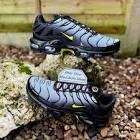

nike_air_max_plus_(tn)/0014.jpg


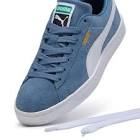

puma_suede_classic/0111.jpg


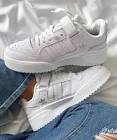

adidas_forum_low/0034.jpg


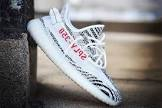

yeezy_boost_350_v2/0075.jpg


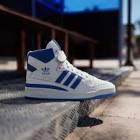

adidas_forum_high/0056.jpg


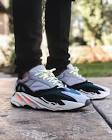

yeezy_700_wave_runner/0047.jpg


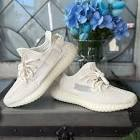

yeezy_boost_350_v2/0093.jpg


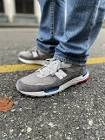

new_balance_992/0056.jpg


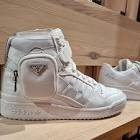

adidas_forum_high/0025.jpg


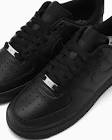

nike_air_force_1_low/0077.jpg


In [99]:
from PIL import Image
from IPython.display import display
import os
# Низкая однородность
sub_df = df.query('background_uniformity < 0.03').sample(10, random_state=42)
for path in sub_df['path']:
    with Image.open(os.path.join(path_to_dataset, path)) as img:
        display(img)
        print(f'{path}')

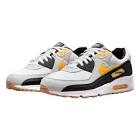

nike_air_max_90/0083.jpg


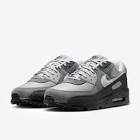

nike_air_max_90/0114.jpg


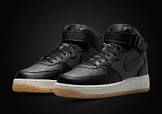

nike_air_force_1_mid/0122.jpg


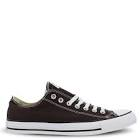

converse_chuck_taylor_all-star_low/0004.jpg


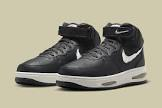

nike_air_force_1_mid/0049.jpg


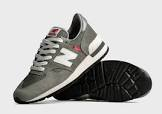

new_balance_990/0032.jpg


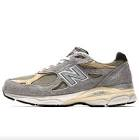

new_balance_990/0005.jpg


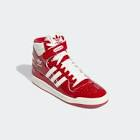

adidas_forum_high/0130.jpg


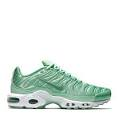

nike_air_max_plus_(tn)/0070.jpg


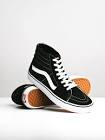

vans_sk8-hi/0043.jpg


In [ ]:
# Высокая однородность
sub_df = df.query('background_uniformity >= 0.03').sample(10, random_state=42)
for path in sub_df['path']:
    with Image.open(os.path.join(path_to_dataset, path)) as img:
        display(img)
        print(f'{path}')

In [101]:
df['uniform_flg'] = (df['background_uniformity'] >= 0.03).astype(int)
df['uniform_flg'].describe()

count    5796.000000
mean        0.668565
std         0.470770
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: uniform_flg, dtype: float64